In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [2]:
df=pd.read_csv("loan_approval_data.csv")

In [3]:
# df.head()
# print(df.info())

df=df.drop("Applicant_ID",axis=1)


to handel  the missing value


In [4]:
catogru_columns=df.select_dtypes(include=["object"]).columns
numerical_columns =df.select_dtypes(include=["float"]).columns

In [5]:
catogru_columns

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [6]:
from sklearn.impute import SimpleImputer
num_imp=SimpleImputer(strategy="mean")
df[numerical_columns]=num_imp.fit_transform(df[numerical_columns])

cat_imp=SimpleImputer(strategy="most_frequent")
df[catogru_columns]=cat_imp.fit_transform(df[catogru_columns])


analize EDA

In [8]:
classes_count=df["Loan_Approved"].value_counts()

Text(0.5, 1.0, 'is loan approve or not')

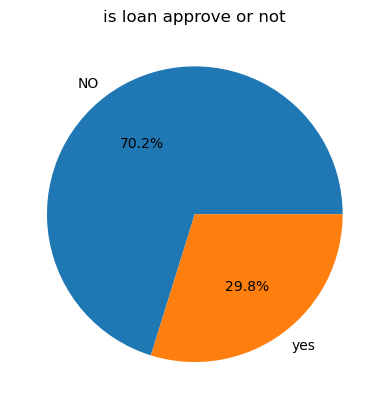

In [9]:
plt.pie(classes_count,labels=["NO","yes"],autopct="%1.1f%%")
plt.title("is loan approve or not")

[Text(0, 0, '621'), Text(0, 0, '379')]

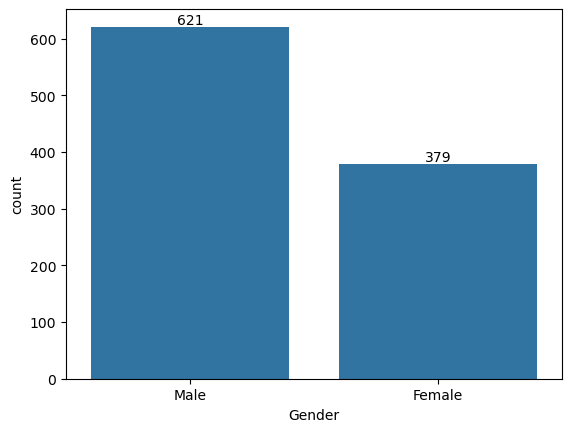

In [10]:
gender_cnt=df["Gender"].value_counts()
ax=sns.barplot(gender_cnt)
ax.bar_label(ax.containers[0])

[Text(0, 0, '722'), Text(0, 0, '278')]

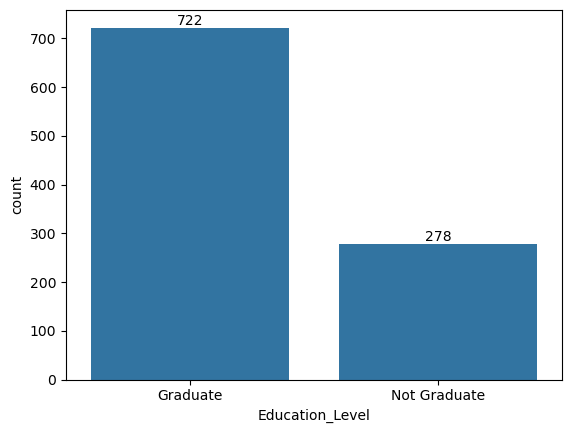

In [11]:
education_cnt=df["Education_Level"].value_counts()
ax=sns.barplot(education_cnt)
ax.bar_label(ax.containers[0])

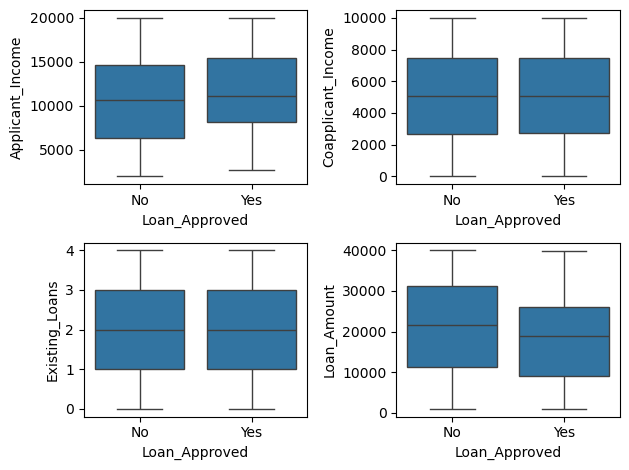

In [12]:



fig, axes=plt.subplots(2,2)
sns.boxplot(ax=axes[0,0], data=df,x="Loan_Approved",y= "Applicant_Income")
sns.boxplot(ax=axes[0,1], data=df,x="Loan_Approved",y= "Coapplicant_Income")
sns.boxplot(ax=axes[1,0], data=df,x="Loan_Approved",y= "Existing_Loans")
sns.boxplot(ax=axes[1,1], data=df,x="Loan_Approved",y= "Loan_Amount")
plt.tight_layout()

In [13]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


<Axes: xlabel='Credit_Score', ylabel='Count'>

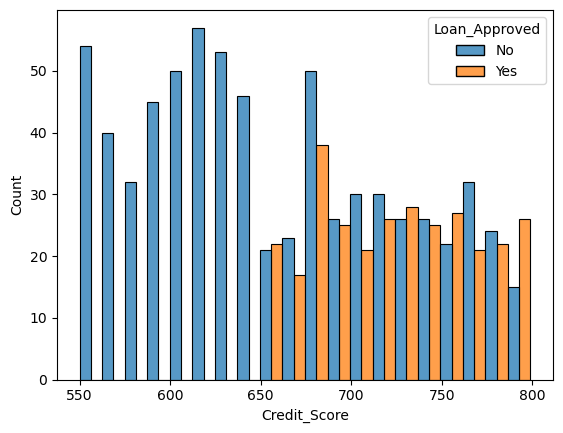

In [14]:
sns.histplot(
    data=df,
    x="Credit_Score",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

ENCODING


In [15]:
from sklearn.preprocessing import OneHotEncoder,LabelEncoder

In [16]:
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

In [17]:
colms=["Marital_Status","Employment_Status","Loan_Purpose","Property_Area","Gender",
      "Employer_Category"]

In [18]:
# label encoding
le=LabelEncoder()
df["Education_Level"]=le.fit_transform(df["Education_Level"])
df["Loan_Approved"]=le.fit_transform(df["Loan_Approved"])

# OneHotCoding
ohe=OneHotEncoder(sparse_output=False,
                 handle_unknown='ignore',
                 drop='first')
encoded=ohe.fit_transform(df[colms])
encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(colms),index=df.index)

df=pd.concat([df.drop(columns=colms),encoded_df],axis=1)
            


<Axes: >

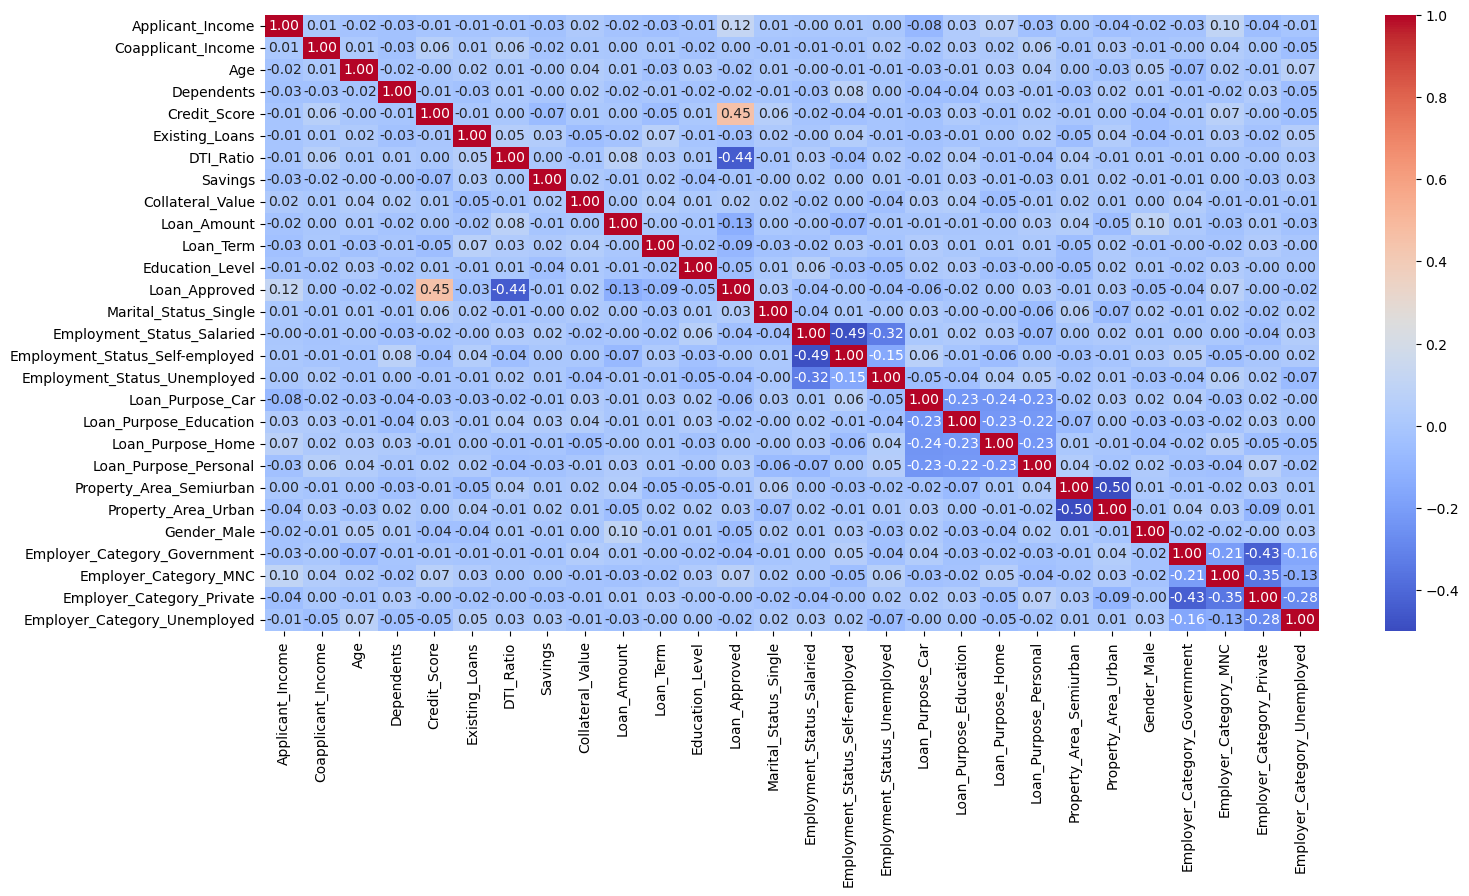

In [19]:
col=df.select_dtypes(include="number")
corr_metrix=col.corr()
plt.figure(figsize=(17,8))
sns.heatmap(
    corr_metrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
    

In [20]:
col.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

Train_test_split + Scaling


In [21]:
x=df.drop("Loan_Approved",axis=1) 
y=df["Loan_Approved"]

In [22]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42)

Train and evaluate model

In [23]:
from sklearn.preprocessing import StandardScaler 
scaler=StandardScaler() 
x_train_scaled=scaler.fit_transform(x_train) 
x_test_scaled=scaler.transform(x_test)

In [25]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train_scaled,y_train)
y_pred=model.predict(x_test_scaled)

# evulate
from sklearn.metrics import (
accuracy_score,confusion_matrix,precision_score,recall_score,f1_score
)

acuuracy=accuracy_score(y_test,y_pred)
confusion = confusion_matrix(y_test,y_pred)
precsion=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print("logistic Regression")
print("accuracy : " ,acuuracy)
print("confusio : ",confusion)
print("precsion : " ,precsion)
print("recall   : ",recall)
print("f1 : ",f1)




logistic Regression
accuracy :  0.865
confusio :  [[126  13]
 [ 14  47]]
precsion :  0.7833333333333333
recall   :  0.7704918032786885
f1 :  0.7768595041322314


In [29]:
# for knn

from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=5)
model.fit(x_train_scaled,y_train)
y_pred=model.predict(x_test_scaled)

# evulate
from sklearn.metrics import (
accuracy_score,confusion_matrix,precision_score,recall_score,f1_score
)

acuuracy=accuracy_score(y_test,y_pred)
confusion = confusion_matrix(y_test,y_pred)
precsion=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print("KNN")
print("accuracy : " ,acuuracy)
print("confusio : ",confusion)
print("precsion : " ,precsion)
print("recall   : ",recall)
print("f1 : ",f1)




KNN
accuracy :  0.76
confusio :  [[120  19]
 [ 29  32]]
precsion :  0.6274509803921569
recall   :  0.5245901639344263
f1 :  0.5714285714285714


In [31]:
# for vanie bais

from sklearn.naive_bayes import GaussianNB
model= GaussianNB()
model.fit(x_train_scaled,y_train)
y_pred=model.predict(x_test_scaled)

# evulate
from sklearn.metrics import (
accuracy_score,confusion_matrix,precision_score,recall_score,f1_score
)

acuuracy=accuracy_score(y_test,y_pred)
confusion = confusion_matrix(y_test,y_pred)
precsion=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print("NAvie bayes")
print("accuracy : " ,acuuracy)
print("confusio : ",confusion)
print("precsion : " ,precsion)
print("recall   : ",recall)
print("f1 : ",f1)




NAvie bayes
accuracy :  0.865
confusio :  [[128  11]
 [ 16  45]]
precsion :  0.8035714285714286
recall   :  0.7377049180327869
f1 :  0.7692307692307693


In [40]:
import pickle
pickle.dump(model,
            open("loan_model.pkl","wb"))
pickle.dump(scaler,
            open("scaler.pkl","wb"))

In [37]:
print(x_train_scaled.shape)

(800, 27)
